# FruIoT MACHINE LEARNING MODEL

**Students**:
- Luca Di Carlo
- Linda Labonia
- Gianmarco Gallo 

## Virtual environment and libraries management

### NOTE: warnings in the output of the tensorflow commands are common if no CUDA drivers are found or when an Intel CPU is found.

For this homework, given the weight and complexity of the Tensorflow library, I chose to use a virtual environment to run this project (**venv**) in order to manage libraries more easily.
To reproduce this process you need to follow the underlying steps:

- Install venv on your machine via terminal with command ```sudo apt install python-venv```;
- Create a virtual environment in your working directory with command ```python3 -m venv <venv_name>```;
- Run the virtual environment on your terminal with command ```source <venv_name>/bin/activate```;
- Install the missing libraries in venv with command ```pip install <library_name>```

It is important to install the ```ipykernel``` library in order to switch from the standard kernel (running your local machine libraries) to the venv kernel. 
To do so you need to write command ```python -m ipykernel install --user --name=<venv_name> --display-name "<venv_name>"``` while running the venv in your terminal.
Once you have done all of this, the only step needed is choosing the venv kernel in your Jupyter Notebook (or Google Colab).

At this point, once the venv is set up with the proper libraries we can proceed with the `import` commands.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import intel_extension_for_tensorflow as itex

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

from tensorflow.keras import layers, models, metrics

2026-05-17 22:05:26.485400: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-17 22:05:26.485427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 22:05:26.485910: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-17 22:05:27.549743: I itex/core/wrapper/itex_gpu_wrapper.cc:38] Intel Extension for Tensorflow* GPU backend is loaded.
2026-05-17 22:05:27.562531: I itex/core/devices/gpu/itex_gpu_runtime.cc:130] Selected platform: Intel(R) oneAPI Unified Runtime over Level-Zero
2026-05-17 22:05:27.562558: I itex/core/devices/gpu/itex_gpu_runtime.cc:155] number of sub-dev

## Dataset import and preprocessing

The chosen dataset is in **.csv** format, so we are dealing with an easy file. Despite the ease, we would still perform some sanity checks on the column to make sure that there is no missing value. 

In [2]:
df = pd.read_csv(
    "../dataset/dataset.csv", 
    sep=',', 
    na_values='?',        # Trasforms '?' in NaN
    low_memory=False      # Helps Pandas with big files
)

print(f"Number of initial dataset entries: {len(df)}")
print(f"Missing values per column:\n{df.isnull().sum().to_string()}")
df = df.dropna()

# I'll only choose the numeric features (from the 3rd to the 9th)
X = df.iloc[:, 2:].astype(float)

print(f"\nNumber of final dataset entries: {len(X)}")

Number of initial dataset entries: 673
Missing values per column:
created_at     0
entry_id       0
raw            0
ratio          0
temperature    0
humidity       0
status         0

Number of final dataset entries: 673


As expected, we built the dataset correctly and we have **no missing value**! So, we can now proceed with the split operation, which will be a **80/20 split**.

In [3]:
# Features: raw, ratio, temperature, humidity
X = df[['raw', 'ratio', 'temperature', 'humidity']].values
# Target: status (0=unripe, 1=mature, 2=ruined)
Y = df['status'].values

# Split: 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# Feature scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler means and variances so you can code them into the ESP32 C++ script
print("\nScaler parameters for ESP32")
print("Means:", scaler.mean_)
print("Variances:", scaler.var_)


Scaler parameters for ESP32
Means: [462.75464684   0.54427414  24.53048327  96.22732342]
Variances: [3.94740773e+04 9.01806035e-02 9.04312406e-01 3.40861493e+01]


## FNN build

We want to build a **Feedforward Neural Network** (FNN) with 4 layers (including the input layer):
- **input layer** of 4 units
- **first hidden layer** of 64 units
- **second hidden layer** of 32 units
- **softmax layer**


In [4]:
# Hyperparameters
input_dim = X_train_scaled.shape[1] # 4 features
num_classes = 3 # 0, 1, 2

# Model architecture
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu', name='hidden_1'),
    layers.Dense(32, activation='relu', name='hidden_2'),
    layers.Dense(num_classes, activation='softmax', name='output')
])

# Compile the model and use sparse_categorical_crossentropy because our targets are integers (0, 1, 2)
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_1 (Dense)            (None, 64)                320       
                                                                 
 hidden_2 (Dense)            (None, 32)                2080      
                                                                 
 output (Dense)              (None, 3)                 99        
                                                                 
Total params: 2499 (9.76 KB)
Trainable params: 2499 (9.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## FNN training and evaluation

This next phase will consist in **training** our FNN and then **evaluating** its performance. To do so, we reckon **50 epochs** should be enough for this task. Moreover, using a part of the training set as a **validation** set will further improve the precision of our model.
The evaluation phase will be done through standard metrics like: **precision**, **accuracy**, **recall**, **F1-score** and **confusion matrix**.

Epoch 1/50
onednn_verbose,v1,info,oneDNN v3.8.0 (commit 5dc2e69f319ab59520c9096436488c11ab86fd93)
onednn_verbose,v1,info,cpu,runtime:DPC++,nthr:1
onednn_verbose,v1,info,cpu,isa:Intel AVX2 with Intel DL Boost, float16 and bfloat16 support
onednn_verbose,v1,info,gpu,runtime:DPC++
onednn_verbose,v1,info,cpu,engine,sycl cpu device count:0 - no devices available.
onednn_verbose,v1,info,gpu,engine,sycl gpu device count:1 
onednn_verbose,v1,info,gpu,engine,0,backend:Level Zero,name:Intel(R) Graphics [0x7d51],driver_version:1.3.29735,binary_kernels:enabled
onednn_verbose,v1,info,graph,backend,0:dnnl_backend
onednn_verbose,v1,info,experimental features are enabled
onednn_verbose,v1,info,use batch_normalization stats one pass is enabled
onednn_verbose,v1,info,GPU convolution v2 is disabled
onednn_verbose,v1,info,experimental functionality for sparse domain is enabled
onednn_verbose,v1,primitive,info,template:operation,engine,primitive,implementation,prop_kind,memory_descriptors,attributes,auxili

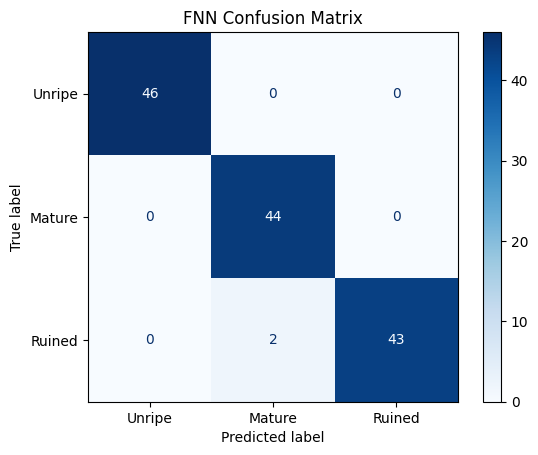

In [5]:
# Train the model
history = model.fit(
    X_train_scaled, Y_train,
    epochs=50, 
    batch_size=16, 
    validation_split=0.15, 
    verbose=1
)

print("\n--- MODEL EVALUATION ---")
# Predict on Test Set
loss, accuracy = model.evaluate(X_test_scaled, Y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
Y_pred_probs = model.predict(X_test_scaled)
Y_pred = np.argmax(Y_pred_probs, axis=1)
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unripe', 'Mature', 'Ruined'])
disp.plot(cmap=plt.cm.Blues)
plt.title('FNN Confusion Matrix')
plt.show()

## FNN export to LiteRT

The final phase of this notebook will consist in compressing our FNN using **LiteRT** for Microcontrollers. After converting the model, we will also apply the **INT8 quantization** to further shrink the size of the compressed model that will run on the ESP32. The final compressed model will be in the form of a **.tflite** file.

In [6]:
# Save the model to a temporary directory first (Prevents the in-memory deadlock)
temp_model_dir = "temp_saved_model"
model.save(temp_model_dir)

def representative_dataset():
    # We only need about 50 samples for accurate calibration
    for i in range(50):
        # Ensure it is strictly float32 and explicitly batched as (1, 4)
        data = np.array([X_train_scaled[i]], dtype=np.float32)
        yield [data]

# 3. Force the conversion to happen on the CPU (prevents GPU driver interference)
with tf.device('/CPU:0'):
    # Load from the saved directory instead of from the Keras model directly
    converter = tf.lite.TFLiteConverter.from_saved_model(temp_model_dir)

    converter.experimental_new_converter = False

    # Apply INT8 Quantization settings
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8  
    converter.inference_output_type = tf.int8  

    tflite_quant_model = converter.convert()

# Save the quantized model to disk
tflite_model_path = "fruiot_model_quantized.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_quant_model)

print(f"Success! Model exported to {tflite_model_path}")
print(f"Quantized Model Size: {len(tflite_quant_model) / 1024:.2f} KB")


INFO:tensorflow:Assets written to: temp_saved_model/assets


2026-05-17 22:05:49,273 - tensorflow - INFO - Assets written to: temp_saved_model/assets


Instructions for updating:
Use `tf.saved_model.load` instead.


2026-05-17 22:05:49,385 - tensorflow - WARNING - From /home/luca/Uni/Magistrale/IoT/FruIoT/model/lib/python3.11/site-packages/tensorflow/lite/python/convert_saved_model.py:42: load (from tensorflow.python.saved_model.loader_impl) is deprecated and will be removed in a future version.
Instructions for updating:
Use `tf.saved_model.load` instead.


INFO:tensorflow:Restoring parameters from temp_saved_model/variables/variables


...

2026-05-17 22:05:49,513 - tensorflow - WARNING - From /home/luca/Uni/Magistrale/IoT/FruIoT/model/lib/python3.11/site-packages/tensorflow/lite/python/util.py:305: convert_variables_to_constants (from tensorflow.python.framework.convert_to_constants) is deprecated and will be removed in a future version.
Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


2026-05-17 22:05:49,514 - tensorflow - WARNING - From /home/luca/Uni/Magistrale/IoT/FruIoT/model/lib/python3.11/site-packages/tensorflow/python/framework/convert_to_constants.py:946: extract_sub_graph (from tensorflow.python.framework.graph_util_impl) is deprecated and will be removed in a future version.
Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
2026-05-17 22:05:49,546 - absl - WARNING - Please consider switching to the new converter by setting experimental_new_converter=True. The old converter is deprecated.
/home/luca/Uni/Magistrale/IoT/FruIoT/model/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Success! Model exported to fruiot_model_quantized.tflite
Quantized Model Size: 5.07 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
